In [3]:
library(tidyverse)

library(grid)
library(gridExtra)
library(patchwork)

source("../evaluation_utils/plots_eda.R")
source("../evaluation_utils/evaluation_funcs.R")

In [4]:
cbPalette <- c("#CC79A7", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00")

# Load data

central_corrected === fedRBE corrected data

In [5]:
data_path <- "../evaluation_data/ccRCC_studies/"

central_uncorrected <- read.csv(
    paste0(data_path, "before/central_intensities_log_UNION.tsv"),
    sep = "\t", header = TRUE, row.names = 1, check.names = FALSE
)

# Load combined metadata from ccRCC_metadata.csv.
# Columns: Sample (sample ID), Condition (Tumor/Normal), Dataset (study/batch).
metadata_raw <- read.csv(
    paste0(data_path, "data/ccRCC_metadata.csv"),
    header = TRUE, row.names = 1
)
metadata <- metadata_raw %>%
    rename(file = Sample, condition = Condition, lab = Dataset) %>%
    column_to_rownames("file")
metadata$file <- rownames(metadata)

central_corrected <- read.csv(
    paste0(data_path, "after/intensities_log_Rcorrected_UNION.tsv"),
    sep = "\t", header = TRUE, row.names = 1, check.names = FALSE
)
fed_corrected <- read.csv(
    paste0(data_path, "after/FedApp_corrected_data.tsv"),
    sep = "\t", header = TRUE, row.names = 1, check.names = FALSE
)

# Align matrices to metadata sample order
central_corrected <- central_corrected[, rownames(metadata)]
central_uncorrected <- central_uncorrected[rownames(central_corrected), rownames(metadata)]
fed_corrected <- fed_corrected[rownames(central_corrected), rownames(metadata)]

cat("Loaded data\n")
cat("Central uncorrected:", nrow(central_uncorrected), "rows\n")
cat("Central corrected:", nrow(central_corrected), "rows\n")
cat("Fed corrected:", nrow(fed_corrected), "rows\n")
cat("Sample metadata:", nrow(metadata), "rows\n\n")

Loaded data
Central uncorrected: 6282 rows
Central corrected: 6282 rows
Fed corrected: 6282 rows
Sample metadata: 887 rows



# Checks

## Diagnostic plots

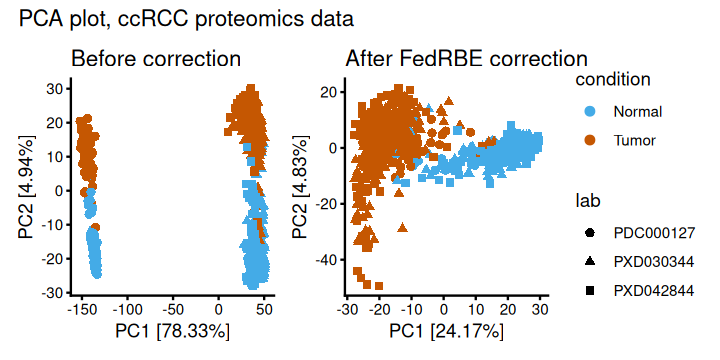

In [6]:
pca_plot_uncorrected <- pca_plot(central_uncorrected, metadata,
    title = "Before correction",
    quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
    show_legend = FALSE, cbPalette = c("#44abe7", "#c55702"))
pca_plot_fed <- pca_plot(fed_corrected, metadata,
    title = "After FedRBE correction",
    quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
    show_legend = TRUE, cbPalette = c("#44abe7", "#c55702"))

layout <- (pca_plot_uncorrected + pca_plot_fed)
layout <- layout + plot_annotation("PCA plot, ccRCC E. coli data")
options(repr.plot.width = 6, repr.plot.height = 3)
layout

Warning message:
“Removed 412190 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 412190 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 412190 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 412190 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 412190 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 412190 rows containing non-finite outside the scale range
(`stat_summary()`).”


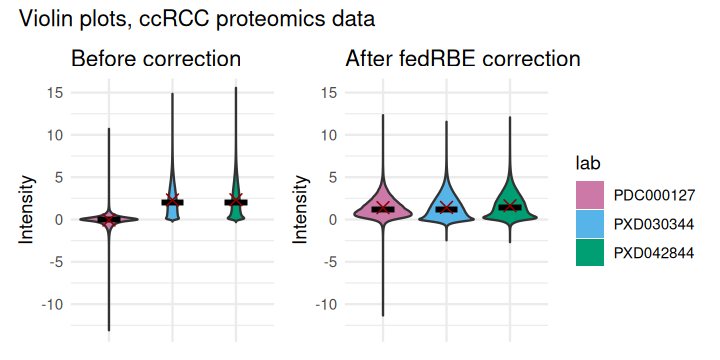

In [7]:
y_min <- min(central_uncorrected, fed_corrected, na.rm = TRUE)
y_max <- max(central_uncorrected, fed_corrected, na.rm = TRUE)
y_limits <- c(y_min, y_max)

boxplots_uncorrected <- boxplot_plot_groupped(central_uncorrected, metadata,
    title = "Before correction",
    quantitativeColumnName = "file",
    color_col = "lab", remove_xnames = TRUE, show_legend = FALSE,
    y_limits = y_limits, cbPalette = cbPalette)

boxplots_fed <- boxplot_plot_groupped(fed_corrected, metadata,
    title = "After fedRBE correction",
    quantitativeColumnName = "file",
    color_col = "lab", remove_xnames = TRUE,
    y_limits = y_limits, cbPalette = cbPalette)

layout <- (boxplots_uncorrected + boxplots_fed)
layout <- layout + plot_annotation("Violin plots, ccRCC E. coli data")
options(repr.plot.width = 6, repr.plot.height = 3)
layout

## Linear model per variable

Following batch effect correction, the percentage of variance explained by the condition should be greater than the batch.

In [8]:
library(variancePartition)

In [9]:
form <- ~ condition + lab

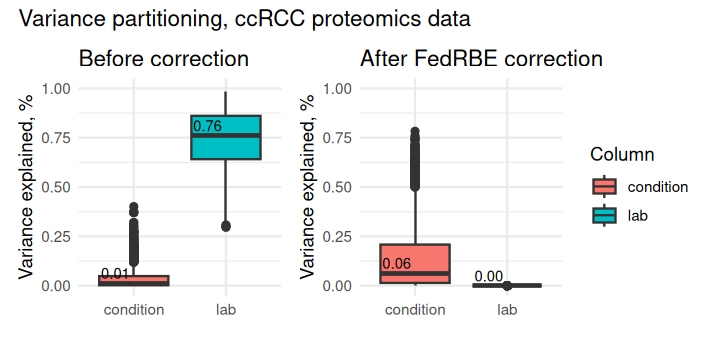

In [10]:
lmpv_plot_fed <- lmpv_plot(fed_corrected, metadata,
    title = "After FedRBE correction", form = form)
lmpv_plot_uncorrected <- lmpv_plot(central_uncorrected, metadata,
    title = "Before correction", show_legend = FALSE, form = form)

layout <- (lmpv_plot_uncorrected + lmpv_plot_fed)
layout <- layout + plot_annotation("Variance partitioning, ccRCC E. coli data")
options(repr.plot.width = 6, repr.plot.height = 3)
layout

# Session info

In [11]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS/LAPACK: /home/yuliya-cosybio/miniforge3/envs/fedRBE/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] variancePartition_1.40.1 BiocParallel_1.44.0      limma_3.66.0            
 [4] viridis_0.6.5            viridisLite_0.4.3        ggsci_4.2.0             
 [7] umap_0.2.10.0            patchwork_1.3.2      